# Notebook 06: Real Population Analysis

This notebook runs the full crossing, equilibrium, and optimization pipeline on the **real SRK genotype data** from *Lepidium papilliferum* (124 ingroup individuals across 24 populations).

**Prerequisites**: Run `00_load_data.ipynb` first to generate `data/population.pkl`.

## Analysis Structure

1. **Within-population analysis** — For each major population (>= 5 individuals), optimize crossing strategy independently
2. **Cross-population analysis** — Treat all 124 individuals as a single population to identify the best crosses species-wide

For both analyses, we simulate **1, 2, and 5 years** (= generations, since *L. papilliferum* is an annual/short-lived perennial) and compare **random mating** vs. **gradient-descent optimized** crossing strategies.

## Key Change from Previous Version

- Genotypes are **directly assigned** from zygosity data (no imputation)
- Individuals are grouped by **Pop** (biological population), not Library

In [1]:
import os
import pickle
import itertools
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import minimize

sns.set_style("whitegrid")
np.random.seed(42)
random.seed(42)

# ---------------------------------------------------------------------------
# Utility functions (from Notebooks 01-04)
# ---------------------------------------------------------------------------

def canonical(alleles):
    return tuple(sorted(alleles))

def allele_frequencies(population, allele_pool=None):
    counts = Counter()
    total = 0
    for genotype in population:
        for allele in genotype:
            counts[allele] += 1
            total += 1
    freqs = {a: counts[a] / total for a in counts}
    if allele_pool is not None:
        for a in allele_pool:
            if a not in freqs:
                freqs[a] = 0.0
    return dict(sorted(freqs.items()))

def form_gametes(genotype):
    return list(itertools.combinations(genotype, 2))

def is_compatible(maternal_genotype, pollen_gamete):
    maternal_alleles = set(maternal_genotype)
    return not any(a in maternal_alleles for a in pollen_gamete)

def cross(parent_a, parent_b):
    maternal_gametes = form_gametes(parent_a)
    paternal_gametes = form_gametes(parent_b)
    compatible_paternal = [g for g in paternal_gametes if is_compatible(parent_a, g)]
    if not compatible_paternal:
        return {}
    offspring_counts = Counter()
    total_combinations = len(maternal_gametes) * len(compatible_paternal)
    for mg in maternal_gametes:
        for pg in compatible_paternal:
            offspring_genotype = canonical(mg + pg)
            offspring_counts[offspring_genotype] += 1
    return {g: count / total_combinations for g, count in sorted(offspring_counts.items())}

def crossing_compatibility(parent_a, parent_b):
    paternal_gametes = form_gametes(parent_b)
    compatible = sum(1 for g in paternal_gametes if is_compatible(parent_a, g))
    return compatible / len(paternal_gametes)

def sample_offspring(parent_a, parent_b):
    offspring_dist = cross(parent_a, parent_b)
    if not offspring_dist:
        return None
    genotypes = list(offspring_dist.keys())
    probs = list(offspring_dist.values())
    idx = np.random.choice(len(genotypes), p=probs)
    return genotypes[idx]

def simulate_generation(population, n_offspring=None, crossing_plan=None):
    if n_offspring is None:
        n_offspring = len(population)
    next_gen = []
    if crossing_plan is not None:
        indices = list(range(len(crossing_plan)))
        weights = np.array([w for _, _, w in crossing_plan])
        weights = weights / weights.sum()
        attempts = 0
        while len(next_gen) < n_offspring and attempts < n_offspring * 20:
            idx = np.random.choice(indices, p=weights)
            mi, pi, _ = crossing_plan[idx]
            child = sample_offspring(population[mi], population[pi])
            if child is not None:
                next_gen.append(child)
            attempts += 1
    else:
        attempts = 0
        n = len(population)
        while len(next_gen) < n_offspring and attempts < n_offspring * 20:
            i, j = random.sample(range(n), 2)
            child = sample_offspring(population[i], population[j])
            if child is not None:
                next_gen.append(child)
            attempts += 1
    return next_gen

def distance_from_equilibrium(population, allele_pool):
    freqs = allele_frequencies(population, allele_pool)
    n = len(allele_pool)
    target = 1.0 / n
    freq_values = np.array([freqs[a] for a in sorted(allele_pool)])
    variance = float(np.var(freq_values))
    chi_squared = float(np.sum((freq_values - target) ** 2 / target))
    eps = 1e-12
    freq_safe = np.maximum(freq_values, eps)
    kl_div = float(np.sum(freq_safe * np.log(freq_safe / target)))
    return {"variance": variance, "chi_squared": chi_squared, "kl_divergence": kl_div}

def enumerate_compatible_crosses(pop, allele_pool):
    compatible_crosses = []
    cross_allele_effects = []
    n_pop = len(pop)
    for i in range(n_pop):
        for j in range(n_pop):
            if i == j:
                continue
            compat = crossing_compatibility(pop[i], pop[j])
            if compat > 0:
                offspring_dist = cross(pop[i], pop[j])
                expected_freqs = {a: 0.0 for a in allele_pool}
                for genotype, prob in offspring_dist.items():
                    for allele in genotype:
                        if allele in expected_freqs:
                            expected_freqs[allele] += prob / 4.0
                compatible_crosses.append((i, j, compat))
                cross_allele_effects.append(expected_freqs)
    allele_effect_matrix = np.array([
        [effects[a] for a in sorted(allele_pool)]
        for effects in cross_allele_effects
    ])
    return compatible_crosses, allele_effect_matrix

def compute_greedy_weights(pop, allele_pool, compatible_crosses, allele_effect_matrix):
    target_freq = 1.0 / len(allele_pool)
    current_freqs = allele_frequencies(pop, allele_pool)
    freq_array = np.array([current_freqs[a] for a in sorted(allele_pool)])
    n_crosses = len(compatible_crosses)
    greedy_scores = np.zeros(n_crosses)
    for k in range(n_crosses):
        deficit = target_freq - freq_array
        boost = allele_effect_matrix[k] - target_freq
        greedy_scores[k] = np.sum(np.maximum(deficit, 0) * np.maximum(boost, 0))
    if greedy_scores.sum() > 0:
        return greedy_scores / greedy_scores.sum()
    return np.ones(n_crosses) / n_crosses

def compute_optimal_weights(compatible_crosses, allele_effect_matrix, allele_pool, maxiter=1000):
    target_freq = 1.0 / len(allele_pool)
    n_crosses = len(compatible_crosses)
    def _fitness_and_grad(weights):
        w = np.abs(weights)
        w_sum = w.sum()
        if w_sum < 1e-12:
            return 1e6, np.zeros(n_crosses)
        w_norm = w / w_sum
        expected = w_norm @ allele_effect_matrix
        diff = expected - target_freq
        chi_sq = float(np.sum(diff ** 2 / target_freq))
        residuals = 2 * diff / target_freq
        g = allele_effect_matrix @ residuals
        grad = (g - np.dot(w_norm, g)) / w_sum
        return chi_sq, grad
    w0 = np.ones(n_crosses) / n_crosses
    result = minimize(
        _fitness_and_grad, w0, method="L-BFGS-B",
        jac=True,
        bounds=[(0, 1)] * n_crosses,
        options={"maxiter": maxiter, "ftol": 1e-12},
    )
    optimal_weights = np.abs(result.x)
    optimal_weights = optimal_weights / optimal_weights.sum()
    return optimal_weights, result

print("All utilities loaded.")

All utilities loaded.


## 1. Load Population Data

In [2]:
DATA_DIR = os.path.join("..", "data")
pkl_path = os.path.join(DATA_DIR, "population.pkl")

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

population = data["population"]
individual_names = data["individual_names"]
allele_pool_full = data["allele_pool"]
name_to_id = data["name_to_id"]
id_to_name = data["id_to_name"]
pop_map = data["pop_map"]
pop_populations = data["pop_populations"]
pop_individuals = data["pop_individuals"]
core_allele_ids = data["core_allele_ids"]

print(f"Population: {len(population)} individuals")
print(f"Full allele pool: {len(allele_pool_full)} alleles")
print(f"Core alleles (in 2+ individuals): {len(core_allele_ids)}")
print(f"Unique genotypes: {len(set(population))}")
print(f"Populations: {len(pop_populations)}")

Population: 124 individuals
Full allele pool: 94 alleles
Core alleles (in 2+ individuals): 53
Unique genotypes: 102
Populations: 24


## 2. Population Overview

Individuals are grouped by the **Pop** field (biological populations). Major populations (>= 5 individuals) are analyzed independently for within-population crossing. All individuals are also analyzed together for cross-population strategy.

In [3]:
# Identify major vs minor populations
MAJOR_POP_THRESHOLD = 5
major_pops = sorted([p for p, inds in pop_populations.items() if len(inds) >= MAJOR_POP_THRESHOLD])
minor_pops = sorted([p for p, inds in pop_populations.items() if len(inds) < MAJOR_POP_THRESHOLD])

pop_colors = {
    "25": "#1f77b4",
    "76": "#ff7f0e",
    "67": "#2ca02c",
    "27": "#d62728",
}

print("=== Major Populations (within-population analysis) ===")
print(f"{'Pop':<8} {'N':>5} {'Alleles':>8} {'Unique geno':>12} {'Chi-sq':>10} {'Variance':>10}")
print("-" * 56)
for pop in major_pops:
    genotypes = pop_populations[pop]
    alleles = sorted(set(a for g in genotypes for a in g))
    d = distance_from_equilibrium(genotypes, alleles)
    print(f"{pop:<8} {len(genotypes):>5} {len(alleles):>8} {len(set(genotypes)):>12} "
          f"{d['chi_squared']:>10.4f} {d['variance']:>10.6f}")

print(f"\n=== Minor Populations ({len(minor_pops)} pops, <{MAJOR_POP_THRESHOLD} individuals each) ===")
minor_total = sum(len(pop_populations[p]) for p in minor_pops)
print(f"Total individuals in minor pops: {minor_total}")
print(f"Populations: {', '.join(f'{p}(n={len(pop_populations[p])})' for p in minor_pops)}")

# Overall stats
all_alleles = sorted(set(a for g in population for a in g))
d_all = distance_from_equilibrium(population, all_alleles)
print(f"\n=== All Individuals Combined ===")
print(f"Total: {len(population)} individuals, {len(all_alleles)} alleles, "
      f"{len(set(population))} unique genotypes")
print(f"Chi-squared: {d_all['chi_squared']:.4f}, Variance: {d_all['variance']:.6f}")

=== Major Populations (within-population analysis) ===
Pop          N  Alleles  Unique geno     Chi-sq   Variance
--------------------------------------------------------
25          31       26           21     1.1813   0.001748
27          15       17           14     0.1333   0.000461
67          22       20           21     0.2707   0.000677
76          27       23           26     0.4119   0.000779

=== Minor Populations (20 pops, <5 individuals each) ===
Total individuals in minor pops: 29
Populations: 118(n=3), 18(n=3), 24(n=1), 24-14(n=1), 26-3(n=1), 29(n=1), 38(n=1), 405(n=1), 48(n=1), 52(n=1), 61(n=1), 68(n=3), 70(n=2), 702-24(n=1), 702-3(n=1), 709(n=1), 712-5(n=1), 715-1(n=1), 8(n=3), 96-16(n=1)

=== All Individuals Combined ===
Total: 124 individuals, 92 alleles, 102 unique genotypes
Chi-squared: 0.7322, Variance: 0.000087


---

# Part A: Within-Population Analysis

For each major population, we:
1. Enumerate SI-compatible crosses
2. Optimize crossing weights using gradient descent
3. Simulate 5 generations (years) comparing random vs. optimized strategies
4. Show allele frequency distributions at Year 0 (baseline), 1, 2, and 5

In [4]:
%%time

# Build per-population data structures
group_data = {}

for pop in major_pops:
    genotypes = pop_populations[pop]
    names = pop_individuals[pop]
    alleles = sorted(set(a for g in genotypes for a in g))
    target = 1.0 / len(alleles)

    cc, aem = enumerate_compatible_crosses(genotypes, alleles)
    n_total = len(genotypes) * (len(genotypes) - 1)

    group_data[pop] = {
        "pop": genotypes,
        "individuals": names,
        "allele_pool": alleles,
        "target_freq": target,
        "compatible_crosses": cc,
        "allele_effect_matrix": aem,
    }

    print(f"Pop {pop}: {len(genotypes)} ind, {len(alleles)} alleles, "
          f"{len(cc)}/{n_total} compatible crosses ({100*len(cc)/n_total:.1f}%)")

Pop 25: 31 ind, 26 alleles, 871/930 compatible crosses (93.7%)
Pop 27: 15 ind, 17 alleles, 206/210 compatible crosses (98.1%)
Pop 67: 22 ind, 20 alleles, 448/462 compatible crosses (97.0%)
Pop 76: 27 ind, 23 alleles, 669/702 compatible crosses (95.3%)
CPU times: user 49 ms, sys: 552 μs, total: 49.5 ms
Wall time: 49.5 ms


In [5]:
%%time

for pop in major_pops:
    gd = group_data[pop]
    cc = gd["compatible_crosses"]
    aem = gd["allele_effect_matrix"]
    alleles = gd["allele_pool"]
    n_crosses = len(cc)
    target = gd["target_freq"]

    # Baseline chi-squared
    w0 = np.ones(n_crosses) / n_crosses
    expected = w0 @ aem
    baseline_chi = float(np.sum((expected - target) ** 2 / target))

    optimal_weights, result = compute_optimal_weights(cc, aem, alleles, maxiter=5000)
    gd["optimal_weights"] = optimal_weights
    gd["opt_result"] = result
    gd["baseline_chi"] = baseline_chi

    print(f"Pop {pop}: baseline chi²={baseline_chi:.4f}, "
          f"optimized chi²={result.fun:.6f}, converged={result.success}")

Pop 25: baseline chi²=0.9828, optimized chi²=0.000001, converged=True
Pop 27: baseline chi²=0.1233, optimized chi²=0.000000, converged=True
Pop 67: baseline chi²=0.2410, optimized chi²=0.000000, converged=True
Pop 76: baseline chi²=0.3550, optimized chi²=0.022370, converged=True
CPU times: user 65.7 ms, sys: 29 ms, total: 94.7 ms
Wall time: 80.5 ms


### Within-Population Simulation (5 Years)

Run adaptive simulations for 5 generations (years). The optimized strategy **recomputes** crossing weights each generation based on the current population state.

In [6]:
N_YEARS = 5
N_TRIALS = 3
SNAPSHOT_YEARS = [0, 1, 2, 5]

def run_adaptive_simulation(pop, allele_pool, n_gen, strategy, n_trials=3, opt_maxiter=200):
    """Run simulation, returning variance trajectory and population snapshots at each generation."""
    all_variances = np.zeros((n_trials, n_gen + 1))
    all_chi_sq = np.zeros((n_trials, n_gen + 1))
    # Store population snapshots from the last trial for frequency plots
    snapshots = {}

    for trial in range(n_trials):
        current_pop = list(pop)
        for gen in range(n_gen + 1):
            d = distance_from_equilibrium(current_pop, allele_pool)
            all_variances[trial, gen] = d["variance"]
            all_chi_sq[trial, gen] = d["chi_squared"]

            # Save snapshot from last trial
            if trial == n_trials - 1:
                snapshots[gen] = list(current_pop)

            if gen < n_gen:
                if strategy == "random":
                    current_pop = simulate_generation(current_pop)
                else:
                    cc, aem = enumerate_compatible_crosses(current_pop, allele_pool)
                    weights, _ = compute_optimal_weights(cc, aem, allele_pool, maxiter=opt_maxiter)
                    plan = [(cc[k][0], cc[k][1], weights[k])
                            for k in range(len(cc)) if weights[k] > 1e-6]
                    current_pop = simulate_generation(current_pop, crossing_plan=plan)

    return {
        "variance_mean": all_variances.mean(axis=0),
        "variance_std": all_variances.std(axis=0),
        "chi_sq_mean": all_chi_sq.mean(axis=0),
        "chi_sq_std": all_chi_sq.std(axis=0),
        "snapshots": snapshots,
    }

np.random.seed(42)
random.seed(42)

for pop_id in major_pops:
    gd = group_data[pop_id]
    pop = gd["pop"]
    alleles = gd["allele_pool"]
    print(f"\nPop {pop_id} ({len(pop)} ind, {len(alleles)} alleles):")

    print("  Random mating...")
    gd["random"] = run_adaptive_simulation(pop, alleles, N_YEARS, "random", N_TRIALS)

    print("  Optimized adaptive...")
    gd["optimized"] = run_adaptive_simulation(pop, alleles, N_YEARS, "optimized", N_TRIALS)

    r = gd["random"]
    o = gd["optimized"]
    for yr in SNAPSHOT_YEARS:
        if yr <= N_YEARS:
            improvement = (1 - o["variance_mean"][yr] / max(r["variance_mean"][yr], 1e-12)) * 100
            print(f"  Year {yr}: Random var={r['variance_mean'][yr]:.6f}, "
                  f"Optimized var={o['variance_mean'][yr]:.6f}, "
                  f"Improvement={improvement:.1f}%")

print("\nDone.")


Pop 25 (31 ind, 26 alleles):
  Random mating...
  Optimized adaptive...


  Year 0: Random var=0.001748, Optimized var=0.001748, Improvement=0.0%
  Year 1: Random var=0.001951, Optimized var=0.000273, Improvement=86.0%
  Year 2: Random var=0.001843, Optimized var=0.000233, Improvement=87.3%
  Year 5: Random var=0.001249, Optimized var=0.000327, Improvement=73.8%

Pop 27 (15 ind, 17 alleles):
  Random mating...
  Optimized adaptive...
  Year 0: Random var=0.000461, Optimized var=0.000461, Improvement=0.0%
  Year 1: Random var=0.001594, Optimized var=0.001453, Improvement=8.9%
  Year 2: Random var=0.001932, Optimized var=0.001910, Improvement=1.1%
  Year 5: Random var=0.002509, Optimized var=0.001910, Improvement=23.9%

Pop 67 (22 ind, 20 alleles):
  Random mating...


  Optimized adaptive...


  Year 0: Random var=0.000677, Optimized var=0.000677, Improvement=0.0%
  Year 1: Random var=0.001215, Optimized var=0.000599, Improvement=50.7%
  Year 2: Random var=0.001538, Optimized var=0.000776, Improvement=49.6%
  Year 5: Random var=0.001942, Optimized var=0.000578, Improvement=70.3%

Pop 76 (27 ind, 23 alleles):
  Random mating...
  Optimized adaptive...


  Year 0: Random var=0.000779, Optimized var=0.000779, Improvement=0.0%
  Year 1: Random var=0.001308, Optimized var=0.000493, Improvement=62.3%
  Year 2: Random var=0.001308, Optimized var=0.000316, Improvement=75.8%
  Year 5: Random var=0.001380, Optimized var=0.000376, Improvement=72.8%

Done.


### Allele Frequency Distributions: Random vs. Optimized Overlay

For each major population, allele frequencies are shown at Year 0, 1, 2, and 5. **Blue bars** = random mating, **red bars** = optimized crossing, overlaid with transparency so both are visible on the same axes. The dashed line shows the NFDS equilibrium target (equal frequency for all alleles). As the red bars flatten toward the target faster than blue, you can see the optimizer's effect.

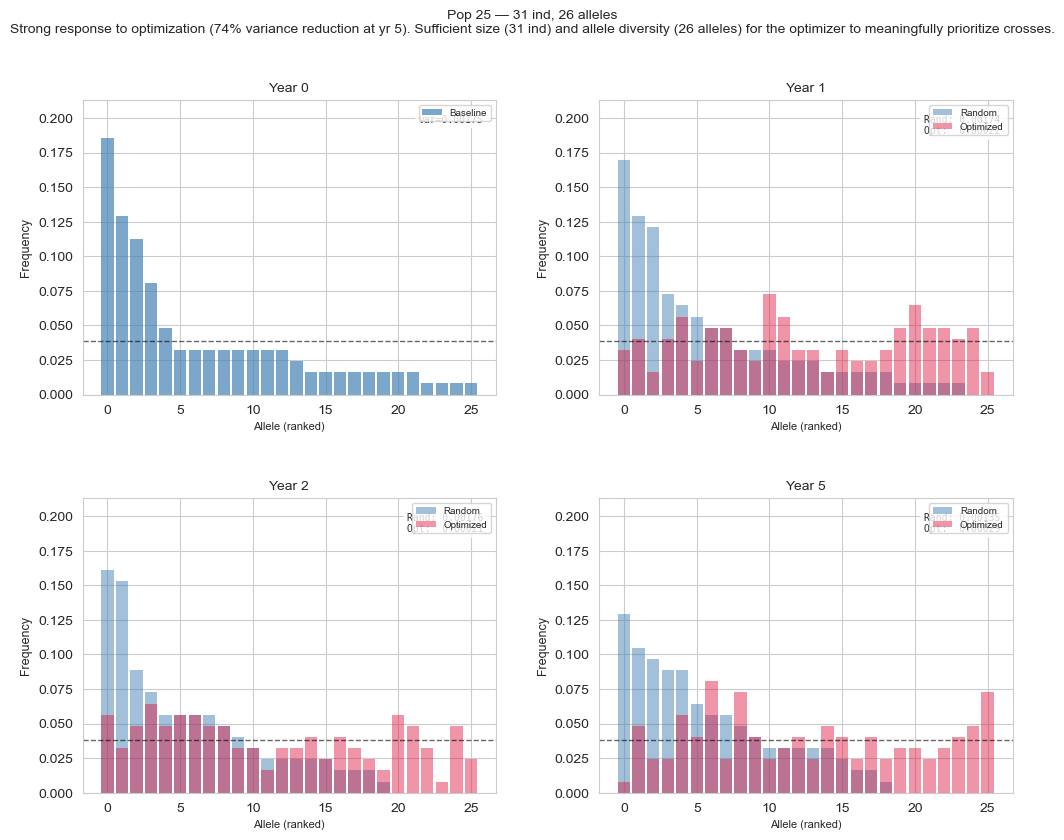

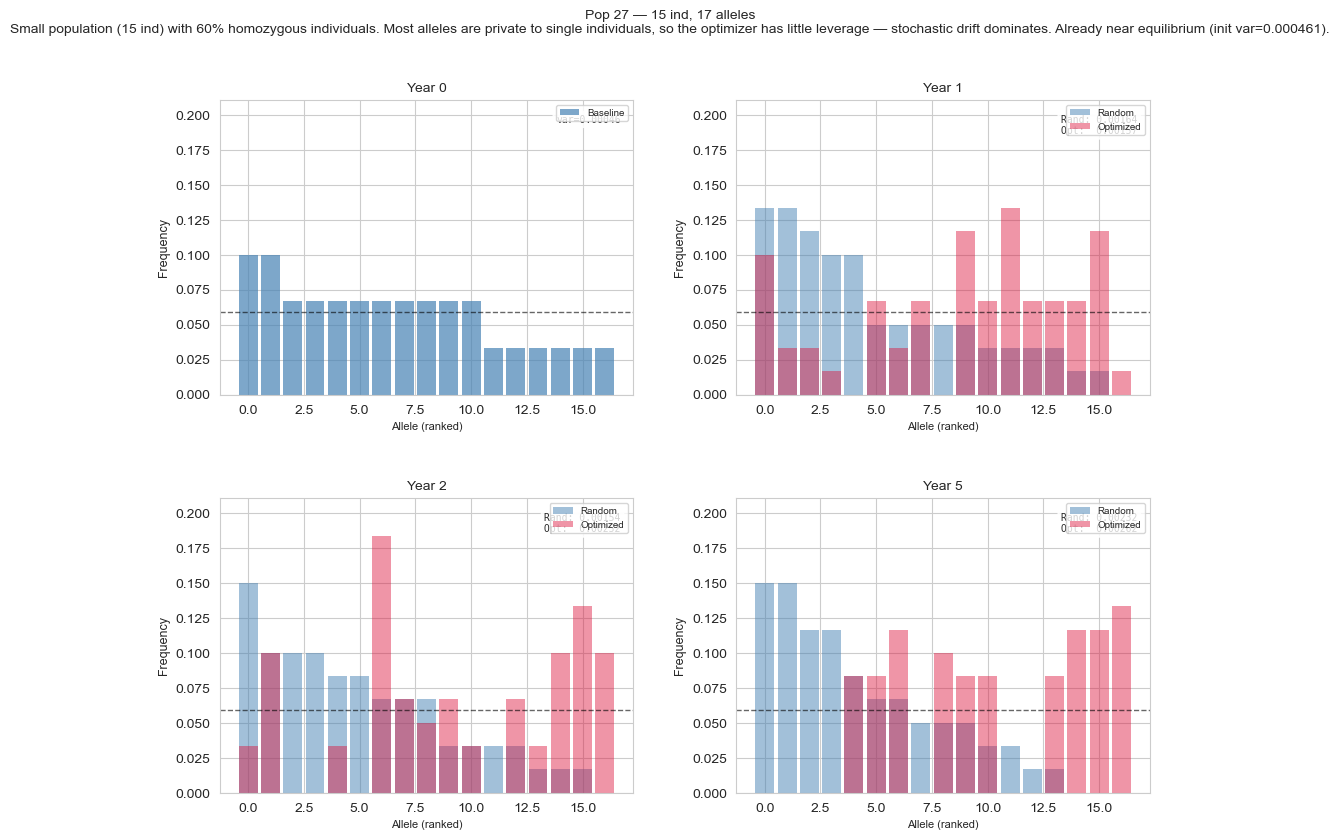

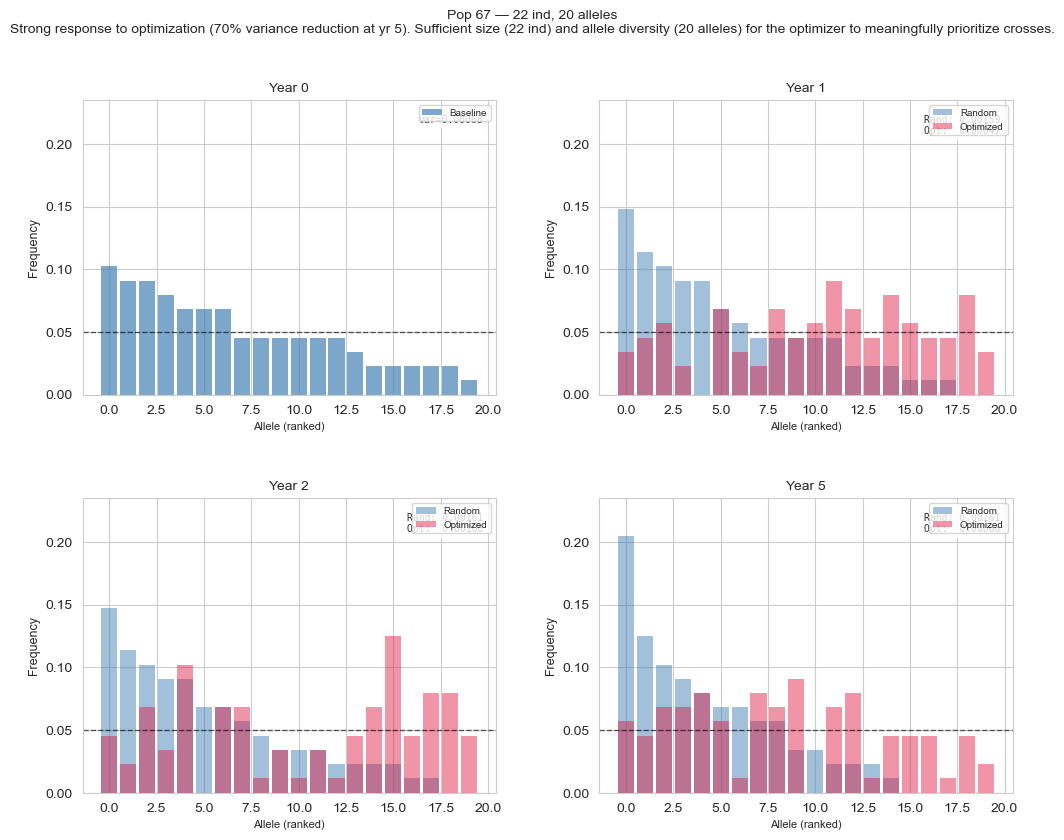

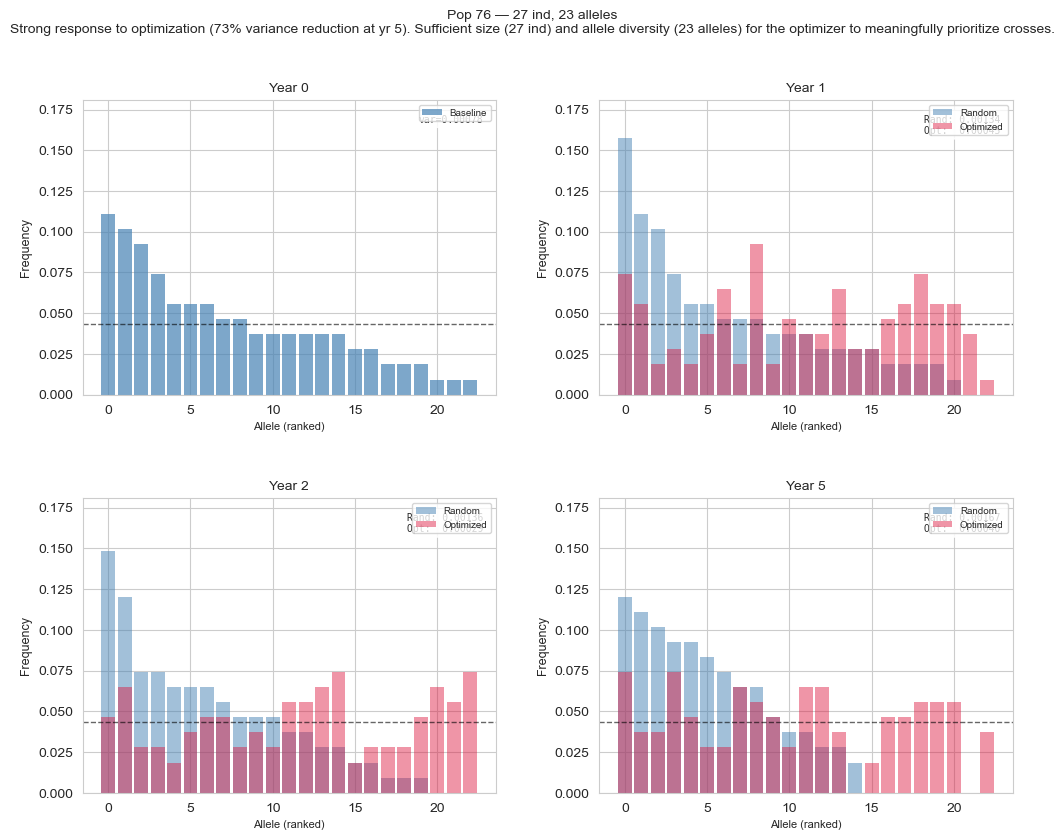

In [7]:
# Per-population performance notes (computed from simulation results)
def pop_performance_note(pop_id, gd):
    """Generate a short performance explanation for a population."""
    genotypes = gd["pop"]
    n = len(genotypes)
    alleles = gd["allele_pool"]
    n_homo = sum(1 for g in genotypes if len(set(g)) == 1)
    pct_homo = 100 * n_homo / n
    d = distance_from_equilibrium(genotypes, alleles)
    yr5_improv = (1 - gd["optimized"]["variance_mean"][5] /
                  max(gd["random"]["variance_mean"][5], 1e-12)) * 100

    if pct_homo > 50 and n < 20:
        return (f"Small population ({n} ind) with {pct_homo:.0f}% homozygous individuals. "
                f"Most alleles are private to single individuals, so the optimizer has little "
                f"leverage — stochastic drift dominates. "
                f"Already near equilibrium (init var={d['variance']:.6f}).")
    elif yr5_improv > 70:
        return (f"Strong response to optimization ({yr5_improv:.0f}% variance reduction at yr 5). "
                f"Sufficient size ({n} ind) and allele diversity ({len(alleles)} alleles) "
                f"for the optimizer to meaningfully prioritize crosses.")
    elif yr5_improv > 40:
        return (f"Moderate response ({yr5_improv:.0f}% variance reduction at yr 5). "
                f"Population size ({n} ind) provides room for improvement, "
                f"though drift still contributes noise.")
    else:
        return (f"Limited optimization benefit ({yr5_improv:.0f}% variance reduction at yr 5). "
                f"Likely constrained by small population size or limited allele diversity.")


for pop_id in major_pops:
    gd = group_data[pop_id]
    alleles = gd["allele_pool"]
    target = gd["target_freq"]
    note = pop_performance_note(pop_id, gd)

    # Determine consistent y-axis across all 4 panels
    y_max = 0
    for yr in SNAPSHOT_YEARS:
        snap_r = gd["random"]["snapshots"].get(yr, gd["pop"])
        snap_o = gd["optimized"]["snapshots"].get(yr, gd["pop"])
        fr = allele_frequencies(snap_r, alleles)
        fo = allele_frequencies(snap_o, alleles)
        y_max = max(y_max, max(fr.values()), max(fo.values()))
    y_max *= 1.15

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f"Pop {pop_id} — {len(gd['pop'])} ind, {len(alleles)} alleles\n{note}",
                 fontsize=10)

    for idx, yr in enumerate(SNAPSHOT_YEARS):
        ax = axes[idx // 2, idx % 2]

        snap_random = gd["random"]["snapshots"].get(yr, gd["pop"])
        snap_optim = gd["optimized"]["snapshots"].get(yr, gd["pop"])

        freqs_random = allele_frequencies(snap_random, alleles)
        freqs_optim = allele_frequencies(snap_optim, alleles)

        # Sort by random-mating frequency for consistent x-ordering
        sorted_alleles = sorted(alleles, key=lambda a: freqs_random.get(a, 0), reverse=True)
        vals_random = [freqs_random.get(a, 0) for a in sorted_alleles]
        vals_optim = [freqs_optim.get(a, 0) for a in sorted_alleles]

        x = np.arange(len(sorted_alleles))

        if yr == 0:
            # Year 0: no treatment yet, just show baseline in blue
            ax.bar(x, vals_random, width=0.85, color="steelblue", alpha=0.7,
                   edgecolor="none", label="Baseline")
            d_r = distance_from_equilibrium(snap_random, alleles)
            ax.text(0.97, 0.95, f"var={d_r['variance']:.5f}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=7,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))
        else:
            # Years 1, 2, 5: overlay random (blue) and optimized (red)
            ax.bar(x, vals_random, width=0.85, color="steelblue", alpha=0.5,
                   edgecolor="none", label="Random")
            ax.bar(x, vals_optim, width=0.85, color="crimson", alpha=0.45,
                   edgecolor="none", label="Optimized")
            d_r = distance_from_equilibrium(snap_random, alleles)
            d_o = distance_from_equilibrium(snap_optim, alleles)
            ax.text(0.97, 0.95,
                    f"Rand: {d_r['variance']:.5f}\nOpt:  {d_o['variance']:.5f}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=7,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

        ax.axhline(y=target, color="black", linestyle="--", alpha=0.6, linewidth=1)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Allele (ranked)", fontsize=8)
        ax.set_ylabel("Frequency", fontsize=9)
        ax.set_title(f"Year {yr}", fontsize=10)
        ax.legend(fontsize=7, loc="upper right")

    plt.subplots_adjust(top=0.88, hspace=0.35, wspace=0.25)
    plt.show()

### Within-Population Convergence Comparison

Variance trajectory over 5 years: random mating (blue) vs. optimized crossing (red). All panels share the same y-axis scale for direct comparison.

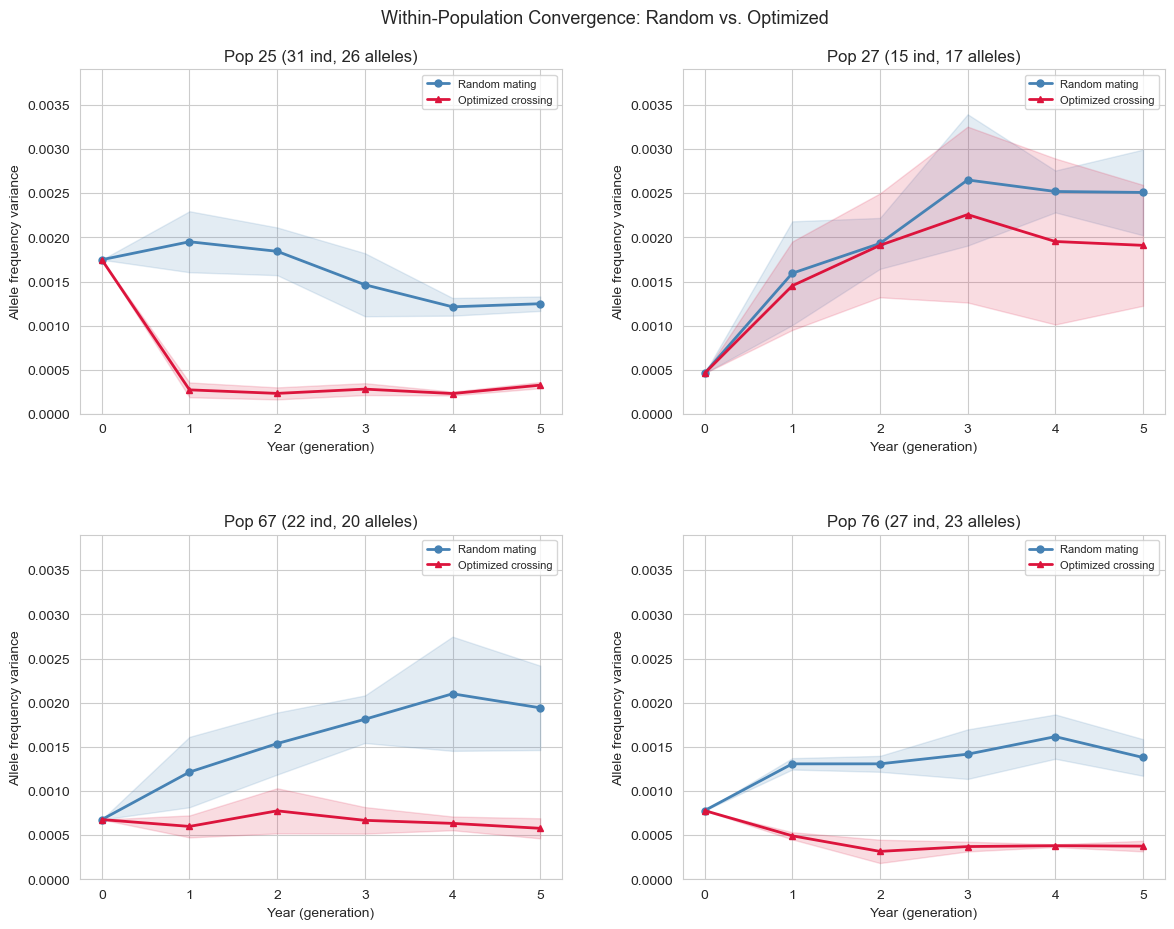

In [8]:
generations = np.arange(N_YEARS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

# Compute shared y-axis maximum across all populations
y_max = 0
for pop_id in major_pops:
    gd = group_data[pop_id]
    for res in [gd["random"], gd["optimized"]]:
        upper = res["variance_mean"] + res["variance_std"]
        y_max = max(y_max, np.max(upper))
y_max *= 1.15

for idx, pop_id in enumerate(major_pops):
    ax = axes_flat[idx]
    gd = group_data[pop_id]
    r = gd["random"]
    o = gd["optimized"]

    ax.plot(generations, r["variance_mean"], "-o", color="steelblue",
            markersize=5, label="Random mating", linewidth=2)
    ax.fill_between(generations,
                    r["variance_mean"] - r["variance_std"],
                    r["variance_mean"] + r["variance_std"],
                    alpha=0.15, color="steelblue")

    ax.plot(generations, o["variance_mean"], "-^", color="crimson",
            markersize=5, label="Optimized crossing", linewidth=2)
    ax.fill_between(generations,
                    o["variance_mean"] - o["variance_std"],
                    o["variance_mean"] + o["variance_std"],
                    alpha=0.15, color="crimson")

    ax.set_xlabel("Year (generation)")
    ax.set_ylabel("Allele frequency variance")
    ax.set_title(f"Pop {pop_id} ({len(gd['pop'])} ind, {len(gd['allele_pool'])} alleles)")
    ax.legend(fontsize=8)
    ax.set_xticks(generations)
    ax.set_ylim(0, y_max)

plt.suptitle("Within-Population Convergence: Random vs. Optimized", fontsize=13)
plt.subplots_adjust(top=0.92, hspace=0.35, wspace=0.25)
plt.show()

### Improvement: Optimized vs. Random

Quantify the % reduction in allele frequency variance at Year 1, 2, and 5 when using optimized crossing vs. random mating.

Within-Population Improvement Summary
Pop  N  Alleles  Initial var  Random var (yr 1)  Optim var (yr 1) Improvement (yr 1)  Random var (yr 2)  Optim var (yr 2) Improvement (yr 2)  Random var (yr 5)  Optim var (yr 5) Improvement (yr 5)
 25 31       26     0.001748           0.001951          0.000273              86.0%           0.001843          0.000233              87.3%           0.001249          0.000327              73.8%
 27 15       17     0.000461           0.001594          0.001453               8.9%           0.001932          0.001910               1.1%           0.002509          0.001910              23.9%
 67 22       20     0.000677           0.001215          0.000599              50.7%           0.001538          0.000776              49.6%           0.001942          0.000578              70.3%
 76 27       23     0.000779           0.001308          0.000493              62.3%           0.001308          0.000316              75.8%           0.001380          0.000

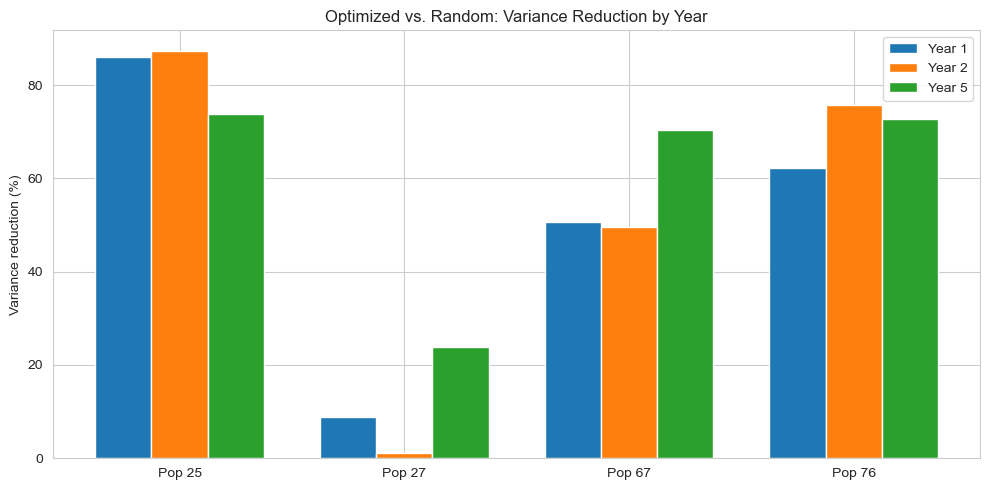

In [9]:
improvement_rows = []
for pop_id in major_pops:
    gd = group_data[pop_id]
    r = gd["random"]
    o = gd["optimized"]
    row = {"Pop": pop_id, "N": len(gd["pop"]), "Alleles": len(gd["allele_pool"]),
           "Initial var": r["variance_mean"][0]}
    for yr in [1, 2, 5]:
        rv = r["variance_mean"][yr]
        ov = o["variance_mean"][yr]
        pct = (1 - ov / max(rv, 1e-12)) * 100
        row[f"Random var (yr {yr})"] = rv
        row[f"Optim var (yr {yr})"] = ov
        row[f"Improvement (yr {yr})"] = f"{pct:.1f}%"
    improvement_rows.append(row)

imp_df = pd.DataFrame(improvement_rows)
print("Within-Population Improvement Summary")
print("=" * 120)
print(imp_df.to_string(index=False, float_format="{:.6f}".format))

# Bar chart of improvement %
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(major_pops))
width = 0.25
for i, yr in enumerate([1, 2, 5]):
    improvements = []
    for pop_id in major_pops:
        gd = group_data[pop_id]
        rv = gd["random"]["variance_mean"][yr]
        ov = gd["optimized"]["variance_mean"][yr]
        improvements.append((1 - ov / max(rv, 1e-12)) * 100)
    ax.bar(x + i * width, improvements, width, label=f"Year {yr}")

ax.set_xticks(x + width)
ax.set_xticklabels([f"Pop {p}" for p in major_pops])
ax.set_ylabel("Variance reduction (%)")
ax.set_title("Optimized vs. Random: Variance Reduction by Year")
ax.legend()
ax.axhline(y=0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

### Top Recommended Crosses (Per Population)

In [10]:
for pop_id in major_pops:
    gd = group_data[pop_id]
    cc = gd["compatible_crosses"]
    ow = gd["optimal_weights"]
    names = gd["individuals"]
    target = gd["target_freq"]
    d = distance_from_equilibrium(gd["pop"], gd["allele_pool"])
    aem = gd["allele_effect_matrix"]

    rows = []
    for k in range(len(cc)):
        i, j, compat = cc[k]
        expected_freqs = aem[k]
        chi_sq = float(np.sum((expected_freqs - target) ** 2 / target))
        impact = d["chi_squared"] - chi_sq
        rows.append({
            "Maternal": names[i], "Pollen donor": names[j],
            "Compatibility": compat, "Impact score": impact,
            "Optimal weight": ow[k],
        })

    df = pd.DataFrame(rows)
    df_top = df.nlargest(10, "Optimal weight").copy()
    df_top.insert(0, "Rank", range(1, len(df_top) + 1))

    print(f"\n{'='*80}")
    print(f"Top 10 Crosses — Pop {pop_id} ({len(gd['pop'])} ind, {len(gd['allele_pool'])} alleles)")
    print(f"{'='*80}")
    print(df_top.to_string(index=False, float_format="{:.4f}".format))


Top 10 Crosses — Pop 25 (31 ind, 26 alleles)
 Rank             Maternal         Pollen donor  Compatibility  Impact score  Optimal weight
    1 Library003_barcode74 Library003_barcode61         0.1667       -2.6937          0.1538
    2 Library003_barcode74 Library003_barcode65         0.1667       -5.9437          0.0756
    3 Library002_barcode31 Library004_barcode83         1.0000       -4.3187          0.0190
    4 Library004_barcode83 Library002_barcode31         1.0000       -4.3187          0.0190
    5 Library004_barcode83 Library006_barcode42         1.0000       -4.3187          0.0190
    6 Library006_barcode42 Library004_barcode83         1.0000       -4.3187          0.0190
    7 Library004_barcode83 Library005_barcode35         1.0000       -4.3187          0.0190
    8 Library005_barcode35 Library004_barcode83         1.0000       -4.3187          0.0190
    9 Library003_barcode71 Library005_barcode24         1.0000       -4.3187          0.0144
   10 Library003_barcode

---

# Part B: Cross-Population Analysis

Treat all 124 ingroup individuals as a **single population** to find optimal crosses across population boundaries. This can introduce rare alleles from one population into another, accelerating species-wide convergence toward NFDS equilibrium.

In [11]:
%%time

global_alleles = sorted(set(a for g in population for a in g))
global_target = 1.0 / len(global_alleles)

print(f"Global population: {len(population)} individuals, {len(global_alleles)} alleles")
print(f"Target frequency: 1/{len(global_alleles)} = {global_target:.4f}")
print(f"Total directed pairs: {len(population) * (len(population) - 1)}")
print("\nEnumerating compatible crosses (this may take a moment)...")

global_cc, global_aem = enumerate_compatible_crosses(population, global_alleles)
n_total = len(population) * (len(population) - 1)

print(f"Compatible crosses: {len(global_cc)}/{n_total} ({100*len(global_cc)/n_total:.1f}%)")
print(f"Effect matrix shape: {global_aem.shape}")

Global population: 124 individuals, 92 alleles
Target frequency: 1/92 = 0.0109
Total directed pairs: 15252

Enumerating compatible crosses (this may take a moment)...


Compatible crosses: 15054/15252 (98.7%)
Effect matrix shape: (15054, 92)
CPU times: user 451 ms, sys: 13.9 ms, total: 465 ms
Wall time: 465 ms


In [12]:
%%time

# Baseline
w0 = np.ones(len(global_cc)) / len(global_cc)
expected = w0 @ global_aem
baseline_chi = float(np.sum((expected - global_target) ** 2 / global_target))

print(f"Optimizing over {len(global_cc)} crosses...")
global_optimal_weights, global_opt_result = compute_optimal_weights(
    global_cc, global_aem, global_alleles, maxiter=5000
)

print(f"Baseline chi²: {baseline_chi:.4f}")
print(f"Optimized chi²: {global_opt_result.fun:.6f}")
print(f"Converged: {global_opt_result.success}, iterations: {global_opt_result.nit}")

Optimizing over 15054 crosses...


Baseline chi²: 0.6808
Optimized chi²: 0.000000
Converged: True, iterations: 667
CPU times: user 3.09 s, sys: 931 ms, total: 4.02 s
Wall time: 2.11 s


In [13]:
np.random.seed(42)
random.seed(42)

print(f"Simulating {N_YEARS} years for {len(population)} individuals...")
print("\nRandom mating...")
global_random = run_adaptive_simulation(population, global_alleles, N_YEARS, "random", N_TRIALS)

print("Optimized adaptive...")
global_optimized = run_adaptive_simulation(population, global_alleles, N_YEARS, "optimized", N_TRIALS)

print("\nResults:")
for yr in SNAPSHOT_YEARS:
    rv = global_random["variance_mean"][yr]
    ov = global_optimized["variance_mean"][yr]
    improvement = (1 - ov / max(rv, 1e-12)) * 100
    print(f"  Year {yr}: Random var={rv:.6f}, Optimized var={ov:.6f}, "
          f"Improvement={improvement:.1f}%")

Simulating 5 years for 124 individuals...

Random mating...
Optimized adaptive...



Results:
  Year 0: Random var=0.000087, Optimized var=0.000087, Improvement=0.0%
  Year 1: Random var=0.000126, Optimized var=0.000026, Improvement=79.8%
  Year 2: Random var=0.000135, Optimized var=0.000024, Improvement=82.0%
  Year 5: Random var=0.000142, Optimized var=0.000023, Improvement=83.9%


### Cross-Population Allele Frequencies: Random vs. Optimized Overlay

Same overlay format: **blue** = random mating, **red** = optimized crossing, both on the same axes with transparency.

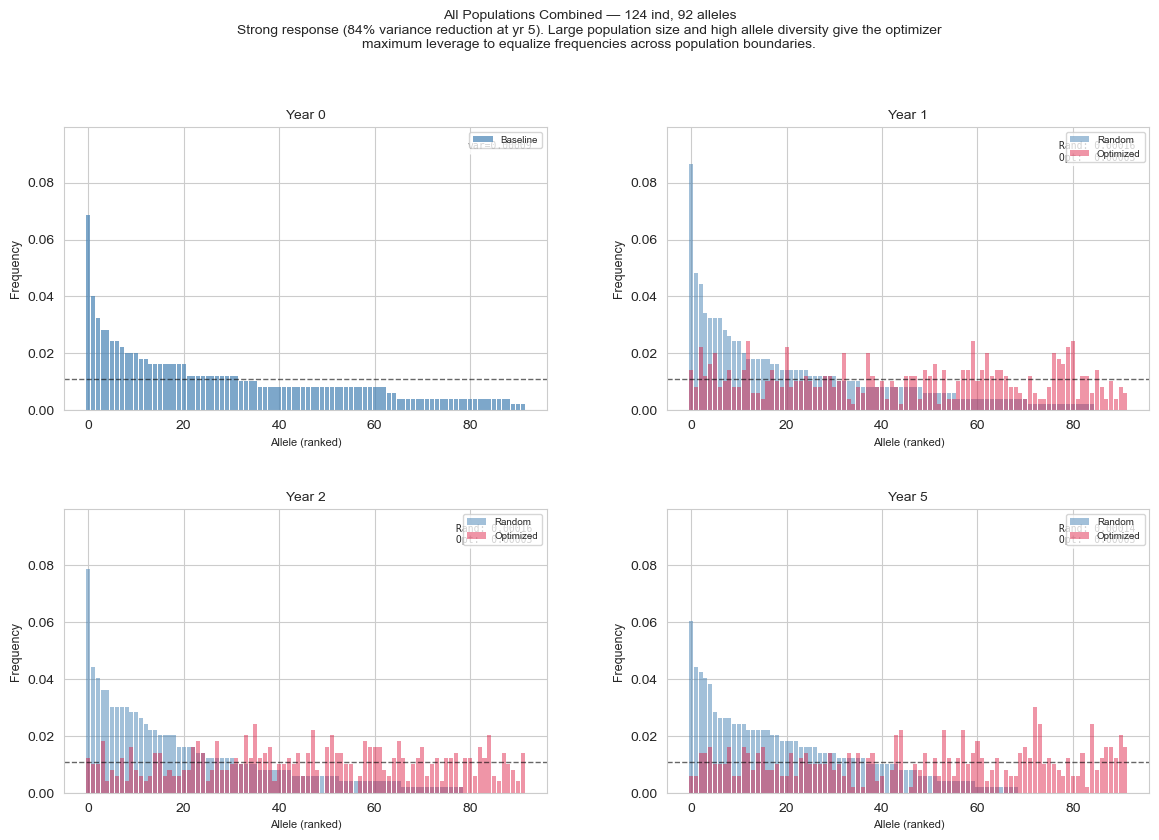

In [14]:
yr5_rv = global_random["variance_mean"][5]
yr5_ov = global_optimized["variance_mean"][5]
yr5_improv = (1 - yr5_ov / max(yr5_rv, 1e-12)) * 100

# Determine consistent y-axis across all 4 panels
y_max = 0
for yr in SNAPSHOT_YEARS:
    snap_r = global_random["snapshots"].get(yr, population)
    snap_o = global_optimized["snapshots"].get(yr, population)
    fr = allele_frequencies(snap_r, global_alleles)
    fo = allele_frequencies(snap_o, global_alleles)
    y_max = max(y_max, max(fr.values()), max(fo.values()))
y_max *= 1.15

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"All Populations Combined — {len(population)} ind, {len(global_alleles)} alleles\n"
             f"Strong response ({yr5_improv:.0f}% variance reduction at yr 5). "
             f"Large population size and high allele diversity give the optimizer\n"
             f"maximum leverage to equalize frequencies across population boundaries.",
             fontsize=10)

for idx, yr in enumerate(SNAPSHOT_YEARS):
    ax = axes[idx // 2, idx % 2]

    snap_random = global_random["snapshots"].get(yr, population)
    snap_optim = global_optimized["snapshots"].get(yr, population)

    freqs_random = allele_frequencies(snap_random, global_alleles)
    freqs_optim = allele_frequencies(snap_optim, global_alleles)

    sorted_alleles = sorted(global_alleles, key=lambda a: freqs_random.get(a, 0), reverse=True)
    vals_random = [freqs_random.get(a, 0) for a in sorted_alleles]
    vals_optim = [freqs_optim.get(a, 0) for a in sorted_alleles]

    x = np.arange(len(sorted_alleles))

    if yr == 0:
        ax.bar(x, vals_random, width=0.85, color="steelblue", alpha=0.7,
               edgecolor="none", label="Baseline")
        d_r = distance_from_equilibrium(snap_random, global_alleles)
        ax.text(0.97, 0.95, f"var={d_r['variance']:.5f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=7,
                family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))
    else:
        ax.bar(x, vals_random, width=0.85, color="steelblue", alpha=0.5,
               edgecolor="none", label="Random")
        ax.bar(x, vals_optim, width=0.85, color="crimson", alpha=0.45,
               edgecolor="none", label="Optimized")
        d_r = distance_from_equilibrium(snap_random, global_alleles)
        d_o = distance_from_equilibrium(snap_optim, global_alleles)
        ax.text(0.97, 0.95,
                f"Rand: {d_r['variance']:.5f}\nOpt:  {d_o['variance']:.5f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=7,
                family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

    ax.axhline(y=global_target, color="black", linestyle="--", alpha=0.6, linewidth=1)
    ax.set_ylim(0, y_max)
    ax.set_xlabel("Allele (ranked)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.set_title(f"Year {yr}", fontsize=10)
    ax.legend(fontsize=7, loc="upper right")

plt.subplots_adjust(top=0.85, hspace=0.35, wspace=0.25)
plt.show()

### Cross-Population Convergence

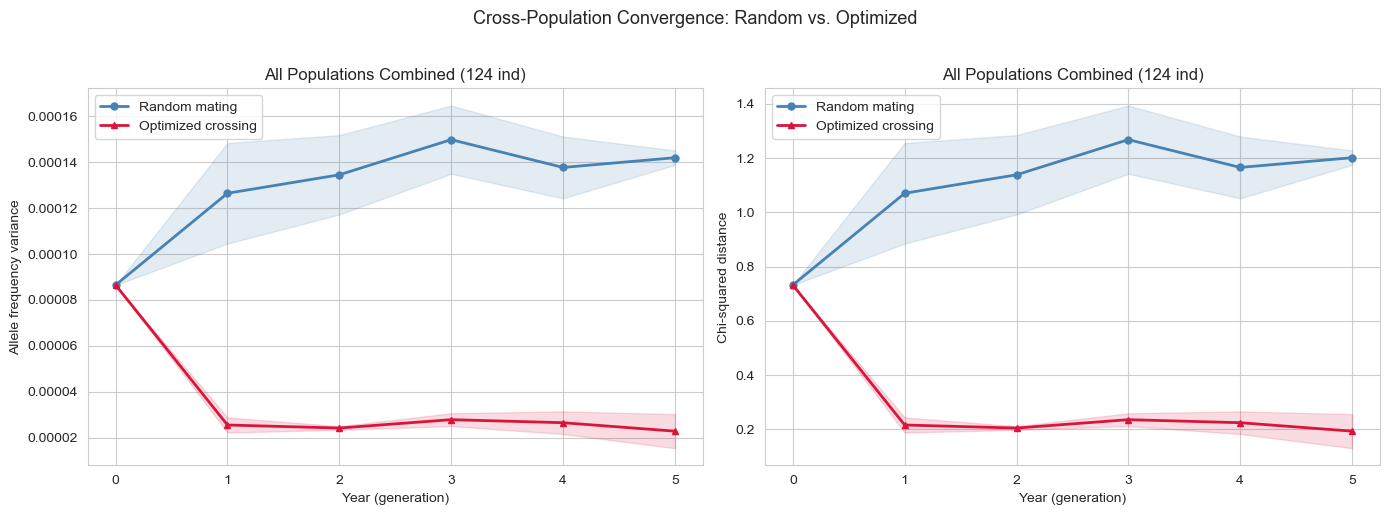

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, ylabel) in zip(axes, [
    ("variance_mean", "Allele frequency variance"),
    ("chi_sq_mean", "Chi-squared distance"),
]):
    ax.plot(generations, global_random[metric], "-o", color="steelblue",
            markersize=5, label="Random mating", linewidth=2)
    ax.fill_between(generations,
                    global_random[metric] - global_random[metric.replace('mean','std')],
                    global_random[metric] + global_random[metric.replace('mean','std')],
                    alpha=0.15, color="steelblue")

    ax.plot(generations, global_optimized[metric], "-^", color="crimson",
            markersize=5, label="Optimized crossing", linewidth=2)
    ax.fill_between(generations,
                    global_optimized[metric] - global_optimized[metric.replace('mean','std')],
                    global_optimized[metric] + global_optimized[metric.replace('mean','std')],
                    alpha=0.15, color="crimson")

    ax.set_xlabel("Year (generation)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"All Populations Combined ({len(population)} ind)")
    ax.legend()
    ax.set_xticks(generations)

plt.suptitle("Cross-Population Convergence: Random vs. Optimized", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Top Cross-Population Recommended Crosses

These crosses may span population boundaries, introducing alleles between populations.

In [16]:
d_global = distance_from_equilibrium(population, global_alleles)

rows = []
for k in range(len(global_cc)):
    i, j, compat = global_cc[k]
    expected_freqs = global_aem[k]
    chi_sq = float(np.sum((expected_freqs - global_target) ** 2 / global_target))
    impact = d_global["chi_squared"] - chi_sq
    rows.append({
        "Maternal": individual_names[i],
        "Mat. Pop": pop_map[individual_names[i]],
        "Pollen donor": individual_names[j],
        "Don. Pop": pop_map[individual_names[j]],
        "Cross type": "inter-pop" if pop_map[individual_names[i]] != pop_map[individual_names[j]] else "intra-pop",
        "Compatibility": compat,
        "Impact score": impact,
        "Optimal weight": global_optimal_weights[k],
    })

df_global = pd.DataFrame(rows)
df_top = df_global.nlargest(20, "Optimal weight").copy()
df_top.insert(0, "Rank", range(1, len(df_top) + 1))

print("Top 20 Cross-Population Crosses")
print("=" * 120)
print(df_top.to_string(index=False, float_format="{:.4f}".format))

# Summary of inter vs intra
n_inter = (df_global["Cross type"] == "inter-pop").sum()
n_intra = (df_global["Cross type"] == "intra-pop").sum()
top20_inter = (df_top["Cross type"] == "inter-pop").sum()
print(f"\nAll compatible crosses: {n_intra} intra-pop, {n_inter} inter-pop")
print(f"Top 20 by weight: {20 - top20_inter} intra-pop, {top20_inter} inter-pop")

Top 20 Cross-Population Crosses
 Rank             Maternal Mat. Pop         Pollen donor Don. Pop Cross type  Compatibility  Impact score  Optimal weight
    1 Library003_barcode74       25 Library003_barcode61       25  intra-pop         0.1667      -15.5178          0.0358
    2 Library006_barcode59       67 Library003_barcode74       25  inter-pop         0.5000      -11.6845          0.0220
    3 Library003_barcode74       25 Library003_barcode65       25  intra-pop         0.1667      -27.0178          0.0216
    4 Library005_barcode07       76 Library005_barcode35       25  inter-pop         0.1667      -27.0178          0.0207
    5 Library004_barcode87       76 Library005_barcode20       76  intra-pop         0.1667      -32.7678          0.0167
    6 Library005_barcode08       76 Library002_barcode35       52  inter-pop         0.1667      -29.8928          0.0144
    7 Library005_barcode01       76 Library001_barcode18     26-3  inter-pop         0.1667      -29.8928         

---

## Summary: All Analyses

Compare within-population and cross-population results side by side.

In [17]:
summary_rows = []

# Within-population rows
for pop_id in major_pops:
    gd = group_data[pop_id]
    r = gd["random"]
    o = gd["optimized"]
    d = distance_from_equilibrium(gd["pop"], gd["allele_pool"])
    row = {
        "Analysis": f"Pop {pop_id}",
        "Individuals": len(gd["pop"]),
        "Alleles": len(gd["allele_pool"]),
        "Crosses": len(gd["compatible_crosses"]),
        "Initial chi-sq": d["chi_squared"],
        "Optimized chi-sq": gd["opt_result"].fun,
    }
    for yr in [1, 2, 5]:
        rv = r["variance_mean"][yr]
        ov = o["variance_mean"][yr]
        row[f"Yr{yr} Random var"] = rv
        row[f"Yr{yr} Optim var"] = ov
        row[f"Yr{yr} Improv"] = f"{(1 - ov / max(rv, 1e-12)) * 100:.0f}%"
    summary_rows.append(row)

# Cross-population row
row = {
    "Analysis": "ALL (cross-pop)",
    "Individuals": len(population),
    "Alleles": len(global_alleles),
    "Crosses": len(global_cc),
    "Initial chi-sq": d_global["chi_squared"],
    "Optimized chi-sq": global_opt_result.fun,
}
for yr in [1, 2, 5]:
    rv = global_random["variance_mean"][yr]
    ov = global_optimized["variance_mean"][yr]
    row[f"Yr{yr} Random var"] = rv
    row[f"Yr{yr} Optim var"] = ov
    row[f"Yr{yr} Improv"] = f"{(1 - ov / max(rv, 1e-12)) * 100:.0f}%"
summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("Complete Analysis Summary")
print("=" * 140)
print(summary_df.to_string(index=False, float_format="{:.6f}".format))

Complete Analysis Summary
       Analysis  Individuals  Alleles  Crosses  Initial chi-sq  Optimized chi-sq  Yr1 Random var  Yr1 Optim var Yr1 Improv  Yr2 Random var  Yr2 Optim var Yr2 Improv  Yr5 Random var  Yr5 Optim var Yr5 Improv
         Pop 25           31       26      871        1.181322          0.000001        0.001951       0.000273        86%        0.001843       0.000233        87%        0.001249       0.000327        74%
         Pop 27           15       17      206        0.133333          0.000000        0.001594       0.001453         9%        0.001932       0.001910         1%        0.002509       0.001910        24%
         Pop 67           22       20      448        0.270661          0.000000        0.001215       0.000599        51%        0.001538       0.000776        50%        0.001942       0.000578        70%
         Pop 76           27       23      669        0.411866          0.022370        0.001308       0.000493        62%        0.001308       0

## Validation

Spot-check key invariants on the real data pipeline.

In [18]:
all_ok = True

# Check within-pop analyses
for pop_id in major_pops:
    gd = group_data[pop_id]
    pop = gd["pop"]
    alleles = gd["allele_pool"]
    cc = gd["compatible_crosses"]
    print(f"--- Pop {pop_id} ---")

    freq_sum = sum(allele_frequencies(pop, alleles).values())
    ok = abs(freq_sum - 1.0) < 1e-10
    print(f"  Freq sum = {freq_sum:.10f} {'OK' if ok else 'FAIL'}")
    all_ok &= ok

    self_ok = all(crossing_compatibility(pop[i], pop[i]) == 0.0 for i in range(len(pop)))
    print(f"  Self-incompatibility: {'OK' if self_ok else 'FAIL'}")
    all_ok &= self_ok

    print(f"  Optimizer converged: {gd['opt_result'].success}")

# Check global analysis
print(f"\n--- Global ---")
freq_sum = sum(allele_frequencies(population, global_alleles).values())
ok = abs(freq_sum - 1.0) < 1e-10
print(f"  Freq sum = {freq_sum:.10f} {'OK' if ok else 'FAIL'}")
all_ok &= ok
print(f"  Optimizer converged: {global_opt_result.success}")

# Offspring spot-check
n_checked = 0
offspring_ok = True
for k in range(min(20, len(global_cc))):
    i, j, _ = global_cc[k]
    offspring_dist = cross(population[i], population[j])
    parent_alleles = set(population[i]) | set(population[j])
    for g in offspring_dist:
        if len(g) != 4 or not all(a in parent_alleles for a in g):
            offspring_ok = False
        n_checked += 1
print(f"  Offspring spot-check ({n_checked} genotypes): {'OK' if offspring_ok else 'FAIL'}")
all_ok &= offspring_ok

print(f"\n{'='*40}")
print(f"{'All checks passed.' if all_ok else 'WARNING: Some checks failed.'}")

--- Pop 25 ---
  Freq sum = 1.0000000000 OK
  Self-incompatibility: OK
  Optimizer converged: True
--- Pop 27 ---
  Freq sum = 1.0000000000 OK
  Self-incompatibility: OK
  Optimizer converged: True
--- Pop 67 ---
  Freq sum = 1.0000000000 OK
  Self-incompatibility: OK
  Optimizer converged: True
--- Pop 76 ---
  Freq sum = 1.0000000000 OK
  Self-incompatibility: OK
  Optimizer converged: True

--- Global ---
  Freq sum = 1.0000000000 OK
  Optimizer converged: True
  Offspring spot-check (108 genotypes): OK

All checks passed.
